# Подготовка обучающей и тестовой выборки, кросс-валидация и подбор гиперпараметров на примере метода ближайших соседей.

Цель лабораторной работы: изучение способов подготовки выборки и подбора гиперпараметров на примере метода ближайших соседей.

# Задание:

- Выберите набор данных (датасет) для решения задачи классификации или регрессии.
- В случае необходимости проведите удаление или заполнение пропусков и кодирование категориальных признаков.
- С использованием метода train_test_split разделите выборку на обучающую и тестовую.
- Обучите модель ближайших соседей для произвольно заданного гиперпараметра K. Оцените качество модели с помощью подходящих для задачи метрик.
- Произведите подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оцените качество оптимальной модели. Используйте не менее двух стратегий кросс-валидации.
- Сравните метрики качества исходной и оптимальной моделей.


## Импорт необходимых библиотек

В этом блоке загружаются все необходимые библиотеки для работы с данными, визуализации и машинного обучения.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Модули sklearn для загрузки данных и предобработки
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Модули sklearn для модели KNN и метрик
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Модули sklearn для кросс-валидации и подбора гиперпараметров
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import validation_curve, learning_curve

# Настройка стиля графиков
sns.set(style="ticks")
%matplotlib inline

print("Все библиотеки успешно импортированы")

Все библиотеки успешно импортированы


## 1. Загрузка и исследование датасета

Для выполнения лабораторной работы выбран датасет **Wine** из библиотеки `sklearn`. Это классический набор данных для задачи многоклассовой классификации.

**Характеристики датасета:**
- **Количество образцов:** 178
- **Количество признаков:** 13 (все числовые, вещественные)
- **Целевая переменная:** 3 класса (сорта вин)
  - `0` — Class 0 (первый сорт вина)
  - `1` — Class 1 (второй сорт вина)
  - `2` — Class 2 (третий сорт вина)

Данные не содержат пропусков и категориальных признаков, что упрощает предобработку.

In [2]:
# Загрузка данных
data = load_wine()

# Преобразуем в DataFrame для удобного просмотра
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target_name'] = df['target'].map({0: 'Class_0', 1: 'Class_1', 2: 'Class_2'})

print(f"Размер датасета: {df.shape}")
print(f"Количество признаков: {data.data.shape[1]}")
print(f"Количество классов: {len(data.target_names)}")
print(f"Названия классов: {data.target_names}")
print(f"\nПервые 5 строк датасета:")
df.head()

Размер датасета: (178, 15)
Количество признаков: 13
Количество классов: 3
Названия классов: ['class_0' 'class_1' 'class_2']

Первые 5 строк датасета:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class_0


### 1.1. Просмотр структуры данных и проверка на пропуски

Выведем информацию о датасете и проверим наличие пропущенных значений.

In [3]:
print("Информация о датасете:")
df.info()

print("\nКоличество пропусков в данных:", df.isnull().sum().sum())
print("Вывод: Пропуски отсутствуют, все данные числовые. Кодирование категориальных признаков не требуется.")

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-nul

### 1.2. Анализ целевой переменной

Посмотрим на распределение классов в целевой переменной.

Распределение классов:
target_name
Class_1    71
Class_0    59
Class_2    48
Name: count, dtype: int64

Количество образцов в каждом классе:
   class_0: 59 образцов (33.1%)
   class_1: 71 образцов (39.9%)
   class_2: 48 образцов (27.0%)


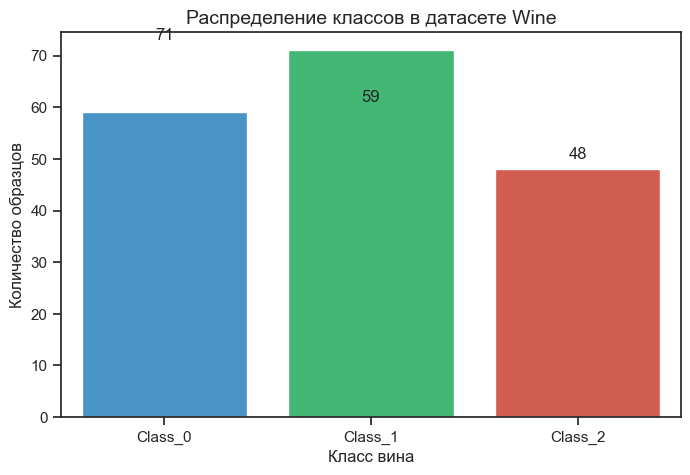

In [4]:
print("Распределение классов:")
print(df['target_name'].value_counts())
print(f"\nКоличество образцов в каждом классе:")
for i, name in enumerate(data.target_names):
    count = np.sum(data.target == i)
    print(f"   {name}: {count} образцов ({count/len(data.target)*100:.1f}%)")

# Визуализация распределения
plt.figure(figsize=(8, 5))
colors = ['#3498DB', '#2ECC71', '#E74C3C']
sns.countplot(data=df, x='target_name', palette=colors)
plt.title('Распределение классов в датасете Wine', fontsize=14)
plt.xlabel('Класс вина', fontsize=12)
plt.ylabel('Количество образцов', fontsize=12)
for i, v in enumerate(df['target_name'].value_counts().values):
    plt.text(i, v + 2, str(v), ha='center', fontsize=12)
plt.show()

### 1.3. Статистическое описание признаков

Анализ описательной статистики показывает, что признаки имеют **разный масштаб**:
- `Alcohol` изменяется в диапазоне ~11-15
- `Malic acid` изменяется в диапазоне ~0.7-5.8
- `Proline` изменяется в диапазоне ~278-1680

Такое различие в масштабах критично для метода K-ближайших соседей, основанного на вычислении расстояний. Поэтому далее будет применено масштабирование.

In [5]:
print("Описательная статистика признаков (первые 5 признаков):")
display(df.describe().round(2).iloc[:, :5])

print("\nВидно, что признаки имеют разные порядки величин:")
print(f"   Alcohol: от {df['alcohol'].min():.1f} до {df['alcohol'].max():.1f}")
print(f"   Proline: от {df['proline'].min():.0f} до {df['proline'].max():.0f}")
print("   Это обосновывает необходимость масштабирования перед применением KNN.")

Описательная статистика признаков (первые 5 признаков):


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium
count,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74
std,0.81,1.12,0.27,3.34,14.28
min,11.03,0.74,1.36,10.60,70.00
25%,12.36,1.60,2.21,17.20,88.00
50%,13.05,1.87,2.36,19.50,98.00
75%,13.68,3.08,2.56,21.50,107.00
max,14.83,5.80,3.23,30.00,162.00



Видно, что признаки имеют разные порядки величин:
   Alcohol: от 11.0 до 14.8
   Proline: от 278 до 1680
   Это обосновывает необходимость масштабирования перед применением KNN.


## 2. Предобработка данных

### 2.1. Масштабирование признаков (StandardScaler)

Метод K-ближайших соседей основан на вычислении расстояний между объектами (обычно используется Евклидово расстояние). Если признаки имеют разный масштаб, признаки с большими числовыми значениями будут доминировать при расчете расстояний.

Для устранения этой проблемы применяется **StandardScaler**, который центрирует данные (вычитает среднее) и нормирует их (делит на стандартное отклонение). После преобразования все признаки имеют:
- Среднее значение ≈ 0
- Стандартное отклонение ≈ 1

In [6]:
# Разделяем на признаки (X) и целевую переменную (y)
X = data.data
y = data.target

# Создаем объект StandardScaler
scaler = StandardScaler()

# Обучаем scaler на ВСЕХ данных и применяем трансформацию
X_scaled = scaler.fit_transform(X)

# Проверяем результат масштабирования
print("Результат масштабирования StandardScaler:")
print("=" * 50)
print(f"   Среднее значение признаков: {X_scaled.mean(axis=0).round(6).mean():.6f}")
print(f"   Стандартное отклонение признаков: {X_scaled.std(axis=0).round(6).mean():.6f}")
print("\nМасштабирование выполнено успешно. Данные готовы к разделению на выборки.")

Результат масштабирования StandardScaler:
   Среднее значение признаков: 0.000000
   Стандартное отклонение признаков: 1.000000

Масштабирование выполнено успешно. Данные готовы к разделению на выборки.


## 3. Разделение выборки на обучающую и тестовую

С помощью функции `train_test_split` исходный датасет разделяется на:
- **Обучающую выборку** — 70% данных (используется для обучения модели и подбора гиперпараметров)
- **Тестовую выборку** — 30% данных (используется только для финальной оценки качества)

**Параметры разделения:**
- `test_size=0.3` — 30% на тест
- `random_state=42` — фиксирует случайное разбиение для воспроизводимости результатов
- `stratify=y` — сохраняет пропорции классов в обучающей и тестовой выборках (стратификация)

In [7]:
# train_test_split с фиксированным random_state
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.3,      # 30% на тест
    random_state=42,    # для воспроизводимости
    stratify=y          # сохраняем пропорции классов
)

print("Разделение данных")
print("=" * 50)
print(f"Размер обучающей выборки: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Размер тестовой выборки:   {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nРаспределение классов в обучающей выборке:")
for i in range(3):
    count = np.sum(y_train == i)
    print(f"   Class {i}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nРаспределение классов в тестовой выборке:")
for i in range(3):
    count = np.sum(y_test == i)
    print(f"   Class {i}: {count} ({count/len(y_test)*100:.1f}%)")

Разделение данных
Размер обучающей выборки: 124 образцов (69.7%)
Размер тестовой выборки:   54 образцов (30.3%)

Распределение классов в обучающей выборке:
   Class 0: 41 (33.1%)
   Class 1: 50 (40.3%)
   Class 2: 33 (26.6%)

Распределение классов в тестовой выборке:
   Class 0: 18 (33.3%)
   Class 1: 21 (38.9%)
   Class 2: 15 (27.8%)


## 4. Обучение модели с произвольным гиперпараметром

### 4.1. Модель KNN с K=5 (произвольный выбор)

Для демонстрации выберем произвольное значение K=5. Это значение часто используется по умолчанию.

Оценим качество модели на обучающей и тестовой выборках. Для многоклассовой классификации будем использовать метрику `weighted` (среднее с учетом поддержки классов).

In [8]:
# Создаем модель с K=5
knn_k5 = KNeighborsClassifier(n_neighbors=5)

# Обучаем модель
knn_k5.fit(X_train, y_train)

# Предсказания
y_train_pred_k5 = knn_k5.predict(X_train)
y_test_pred_k5 = knn_k5.predict(X_test)

# Оценка качества
train_acc_k5 = accuracy_score(y_train, y_train_pred_k5)
test_acc_k5 = accuracy_score(y_test, y_test_pred_k5)

print("Модель KNN (K = 5) — произвольный гиперпараметр")
print("=" * 50)
print(f"\nAccuracy на обучающей выборке: {train_acc_k5:.4f}")
print(f"Accuracy на тестовой выборке:   {test_acc_k5:.4f}")
print(f"\nРазница (Train - Test): {train_acc_k5 - test_acc_k5:.4f}")

print("\nДетальные метрики на тестовой выборке (weighted average):")
print(f"   Precision: {precision_score(y_test, y_test_pred_k5, average='weighted'):.4f}")
print(f"   Recall:    {recall_score(y_test, y_test_pred_k5, average='weighted'):.4f}")
print(f"   F1-score:  {f1_score(y_test, y_test_pred_k5, average='weighted'):.4f}")

print("\nПолный отчет по классификации (тестовая выборка):")
print(classification_report(y_test, y_test_pred_k5, target_names=['Class_0', 'Class_1', 'Class_2']))

Модель KNN (K = 5) — произвольный гиперпараметр

Accuracy на обучающей выборке: 0.9839
Accuracy на тестовой выборке:   0.9444

Разница (Train - Test): 0.0394

Детальные метрики на тестовой выборке (weighted average):
   Precision: 0.9537
   Recall:    0.9444
   F1-score:  0.9448

Полный отчет по классификации (тестовая выборка):
              precision    recall  f1-score   support

     Class_0       1.00      1.00      1.00        18
     Class_1       1.00      0.86      0.92        21
     Class_2       0.83      1.00      0.91        15

    accuracy                           0.94        54
   macro avg       0.94      0.95      0.94        54
weighted avg       0.95      0.94      0.94        54



### 4.2. Матрица ошибок для K=5

Матрица ошибок показывает распределение правильных и неправильных предсказаний модели для каждого класса.

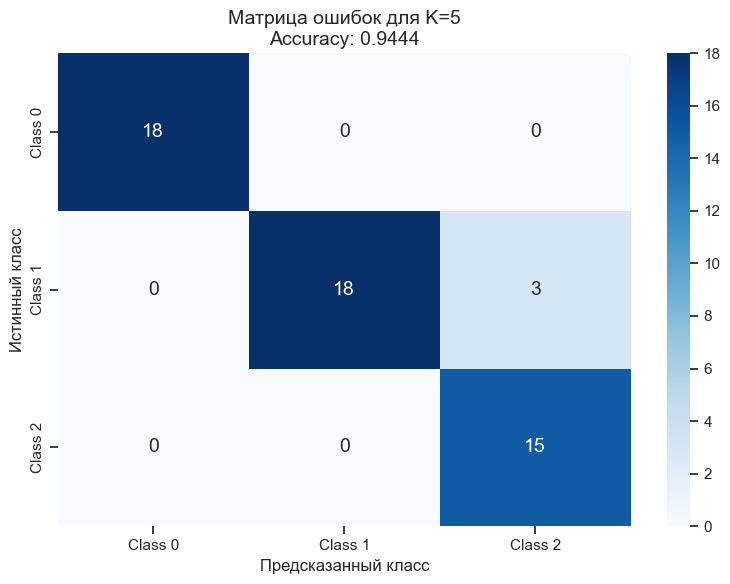

Анализ матрицы ошибок:
Правильно классифицировано: 51 из 54
Ошибок классификации: 3 из 54


In [9]:
# Построение матрицы ошибок
cm_k5 = confusion_matrix(y_test, y_test_pred_k5)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_k5, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'],
            annot_kws={'size': 14})
plt.title(f'Матрица ошибок для K=5\nAccuracy: {test_acc_k5:.4f}', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.tight_layout()
plt.show()

print("Анализ матрицы ошибок:")
print("=" * 50)
print(f"Правильно классифицировано: {np.trace(cm_k5)} из {len(y_test)}")
print(f"Ошибок классификации: {len(y_test) - np.trace(cm_k5)} из {len(y_test)}")

### 4.3. Кросс-валидация для оценки стабильности модели

Однократное разбиение на обучающую и тестовую выборки может дать смещенную оценку качества. Для получения более объективной оценки используется **кросс-валидация** (cross-validation).

Используем `StratifiedKFold` с 5 фолдами для сохранения пропорций классов.

In [10]:
# Оценка модели K=5 с помощью кросс-валидации
cv_scores_k5 = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)

print("Кросс-валидация для модели K=5 (5 фолдов)")
print("=" * 60)
print(f"Значения accuracy по фолдам:")
for i, score in enumerate(cv_scores_k5, 1):
    print(f"   Фолд {i}: {score:.4f}")
print(f"\nСредняя accuracy: {cv_scores_k5.mean():.4f} (+/- {cv_scores_k5.std() * 2:.4f})")
print(f"\nСравнение с accuracy на одном тестовом разбиении: {test_acc_k5:.4f}")
print(f"Разница между CV-оценкой и тестовой: {abs(cv_scores_k5.mean() - test_acc_k5):.4f}")

Кросс-валидация для модели K=5 (5 фолдов)
Значения accuracy по фолдам:
   Фолд 1: 0.9600
   Фолд 2: 1.0000
   Фолд 3: 0.9600
   Фолд 4: 0.9200
   Фолд 5: 1.0000

Средняя accuracy: 0.9680 (+/- 0.0599)

Сравнение с accuracy на одном тестовом разбиении: 0.9444
Разница между CV-оценкой и тестовой: 0.0236


## 5. Подбор гиперпараметра K с помощью GridSearchCV

### 5.1. Определение сетки параметров

**GridSearchCV** выполняет полный перебор по заданной сетке гиперпараметров, для каждого значения вычисляя качество модели с помощью кросс-валидации.

**Диапазон поиска:** K от 1 до 30 соседей.

In [11]:
# Определяем диапазон поиска K
param_grid = {'n_neighbors': np.arange(1, 31)}

print(f"Сетка параметров для GridSearchCV")
print("=" * 50)
print(f"Параметр: n_neighbors")
print(f"Диапазон: от {param_grid['n_neighbors'][0]} до {param_grid['n_neighbors'][-1]}")
print(f"Всего значений: {len(param_grid['n_neighbors'])}")

Сетка параметров для GridSearchCV
Параметр: n_neighbors
Диапазон: от 1 до 30
Всего значений: 30


### 5.2. GridSearchCV с кросс-валидацией KFold

**KFold** — базовая стратегия кросс-валидации, при которой данные просто разбиваются на `k` последовательных частей без учета распределения классов.

**Параметры:**
- `n_splits=5` — количество фолдов
- `shuffle=True` — перемешивание данных перед разбиением
- `random_state=42` — фиксация случайности для воспроизводимости

In [12]:
# Стратегия 1: KFold
cv_kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_kfold = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv_kfold,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

# Запускаем поиск
print("Выполняется GridSearchCV с KFold...")
grid_kfold.fit(X_train, y_train)
print("Поиск завершен!")

print("\nРезультаты GridSearchCV (KFold)")
print("=" * 50)
print(f"Лучший параметр K: {grid_kfold.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная accuracy: {grid_kfold.best_score_:.4f}")

Выполняется GridSearchCV с KFold...
Поиск завершен!

Результаты GridSearchCV (KFold)
Лучший параметр K: 12
Лучшая кросс-валидационная accuracy: 0.9757


### 5.3. GridSearchCV с кросс-валидацией StratifiedKFold

**StratifiedKFold** — улучшенная стратегия кросс-валидации, которая при разбиении на фолды **сохраняет пропорции классов**. Это особенно важно для несбалансированных данных.

В нашем датасете классы имеют разную представленность, поэтому стратификация может дать более стабильные и надежные оценки.

In [13]:
# Стратегия 2: StratifiedKFold
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_stratified = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv_stratified,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

# Запускаем поиск
print("Выполняется GridSearchCV со StratifiedKFold...")
grid_stratified.fit(X_train, y_train)
print("Поиск завершен!")

print("\nРезультаты GridSearchCV (StratifiedKFold)")
print("=" * 50)
print(f"Лучший параметр K: {grid_stratified.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная accuracy: {grid_stratified.best_score_:.4f}")

Выполняется GridSearchCV со StratifiedKFold...
Поиск завершен!

Результаты GridSearchCV (StratifiedKFold)
Лучший параметр K: 24
Лучшая кросс-валидационная accuracy: 0.9760


### 5.4. Сравнение стратегий кросс-валидации

Построим график зависимости accuracy от значения K для обеих стратегий кросс-валидации.

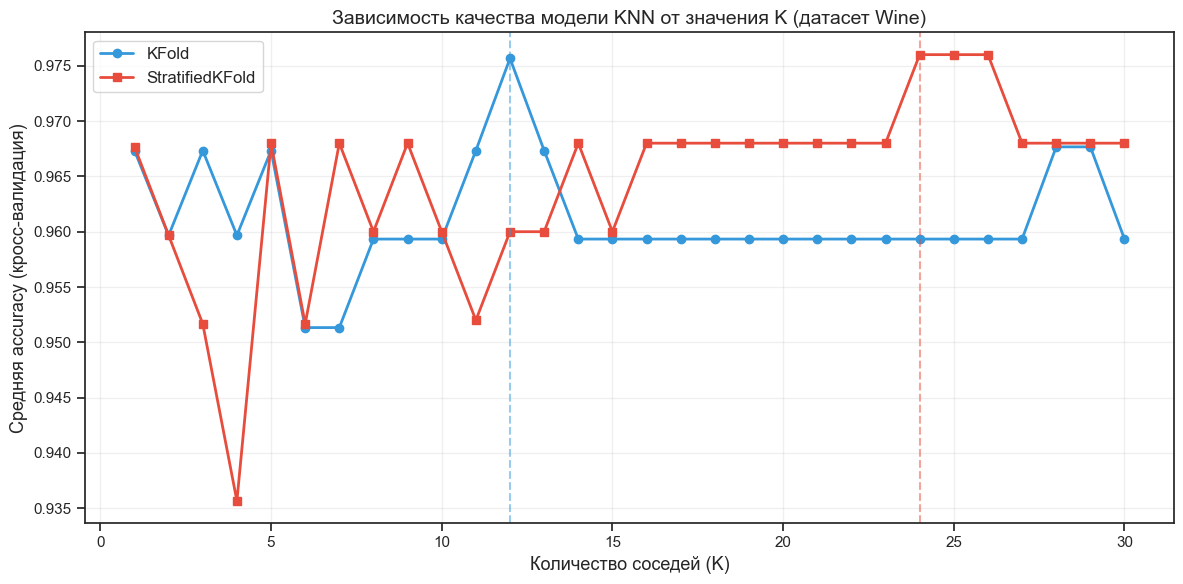

Сравнение стратегий кросс-валидации
   KFold:           оптимальное K = 12, CV accuracy = 0.9757
   StratifiedKFold: оптимальное K = 24, CV accuracy = 0.9760


In [14]:
# Извлечение результатов
k_values = param_grid['n_neighbors']
kfold_scores = grid_kfold.cv_results_['mean_test_score']
stratified_scores = grid_stratified.cv_results_['mean_test_score']

plt.figure(figsize=(12, 6))
plt.plot(k_values, kfold_scores, 'o-', color='#3498DB', linewidth=2, markersize=6, label='KFold')
plt.plot(k_values, stratified_scores, 's-', color='#E74C3C', linewidth=2, markersize=6, label='StratifiedKFold')

# Отмечаем оптимальные значения
plt.axvline(x=grid_kfold.best_params_['n_neighbors'], color='#3498DB', linestyle='--', alpha=0.5)
plt.axvline(x=grid_stratified.best_params_['n_neighbors'], color='#E74C3C', linestyle='--', alpha=0.5)

plt.xlabel('Количество соседей (K)', fontsize=13)
plt.ylabel('Средняя accuracy (кросс-валидация)', fontsize=13)
plt.title('Зависимость качества модели KNN от значения K (датасет Wine)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Сравнение стратегий кросс-валидации")
print("=" * 50)
print(f"   KFold:           оптимальное K = {grid_kfold.best_params_['n_neighbors']}, CV accuracy = {grid_kfold.best_score_:.4f}")
print(f"   StratifiedKFold: оптимальное K = {grid_stratified.best_params_['n_neighbors']}, CV accuracy = {grid_stratified.best_score_:.4f}")

## 6. Подбор гиперпараметра с помощью RandomizedSearchCV

**RandomizedSearchCV** — альтернатива полному перебору GridSearchCV. Вместо проверки всех значений из сетки, он случайным образом выбирает `n_iter` значений.

**Преимущества:**
- Работает быстрее при больших сетках параметров
- Часто находит близкое к оптимальному решение

**Параметры:**
- `n_iter=15` — проверить 15 случайных значений K
- `cv=StratifiedKFold(n_splits=5)` — стратифицированная кросс-валидация

In [15]:
random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=param_grid,
    n_iter=15,                  # проверить 15 случайных K
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

print("Выполняется RandomizedSearchCV...")
random_search.fit(X_train, y_train)
print("Поиск завершен!")

print("\nРезультаты RandomizedSearchCV")
print("=" * 50)
print(f"Лучший параметр K: {random_search.best_params_['n_neighbors']}")
print(f"Лучшая кросс-валидационная accuracy: {random_search.best_score_:.4f}")

print("\nСравнение с GridSearchCV:")
print(f"   GridSearchCV (StratifiedKFold): K={grid_stratified.best_params_['n_neighbors']}, Accuracy={grid_stratified.best_score_:.4f}")
print(f"   RandomizedSearchCV:             K={random_search.best_params_['n_neighbors']}, Accuracy={random_search.best_score_:.4f}")

Выполняется RandomizedSearchCV...
Поиск завершен!

Результаты RandomizedSearchCV
Лучший параметр K: 24
Лучшая кросс-валидационная accuracy: 0.9760

Сравнение с GridSearchCV:
   GridSearchCV (StratifiedKFold): K=24, Accuracy=0.9760
   RandomizedSearchCV:             K=24, Accuracy=0.9760


## 7. Кривая валидации (Validation Curve)

Кривая валидации показывает, как изменяется качество модели на обучающей и валидационной выборках в зависимости от значения гиперпараметра K.

**Что можно увидеть на графике:**
- При малых K: модель **переобучается** (высокая точность на трейне, падение на валидации)
- При больших K: модель **недообучается** (точность падает и на трейне, и на валидации)
- Оптимум находится в "золотой середине"

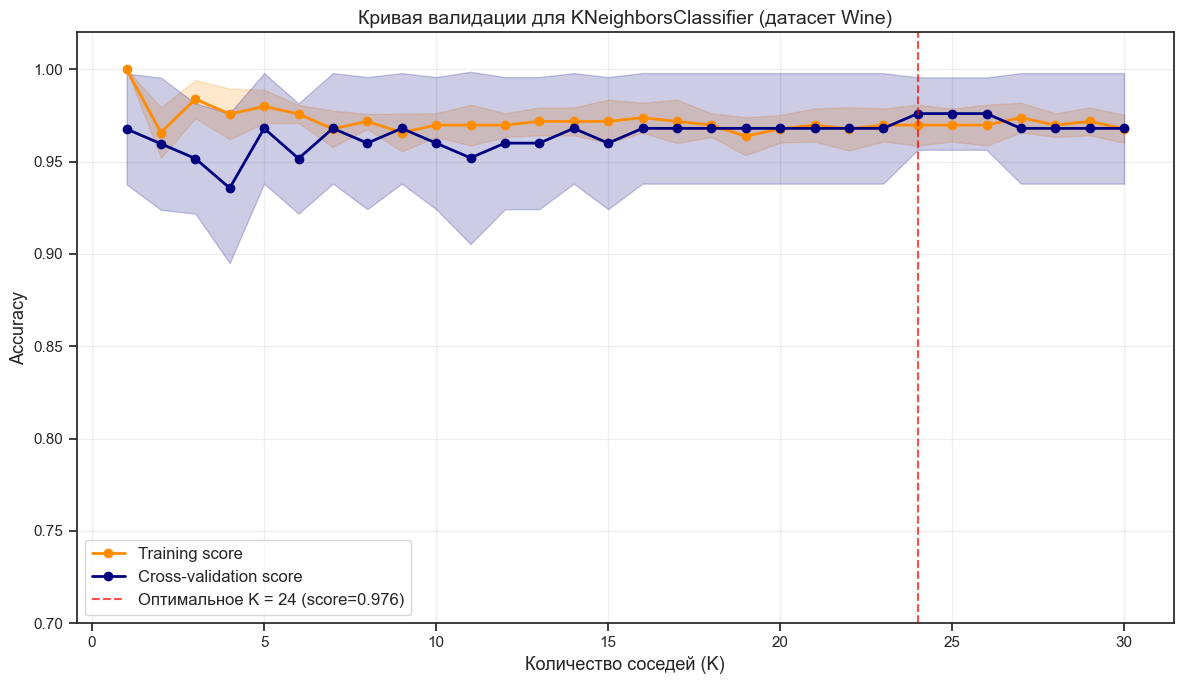

По кривой валидации:
   Оптимальное K = 24
   Максимальная CV Accuracy = 0.9760


In [16]:
# Функция построения кривой валидации
def plot_validation_curve(X, y, param_range, cv):
    train_scores, test_scores = validation_curve(
        KNeighborsClassifier(), X, y,
        param_name="n_neighbors",
        param_range=param_range,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(12, 7))
    plt.title("Кривая валидации для KNeighborsClassifier (датасет Wine)", fontsize=14)
    plt.xlabel("Количество соседей (K)", fontsize=13)
    plt.ylabel("Accuracy", fontsize=13)
    plt.ylim(0.70, 1.02)
    plt.grid(True, alpha=0.3)
    
    # Training score
    plt.plot(param_range, train_mean, 'o-', color="darkorange", label="Training score", linewidth=2)
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, 
                     alpha=0.2, color="darkorange")
    
    # Cross-validation score
    plt.plot(param_range, test_mean, 'o-', color="navy", label="Cross-validation score", linewidth=2)
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std,
                     alpha=0.2, color="navy")
    
    # Отмечаем оптимальное K
    optimal_k = param_range[np.argmax(test_mean)]
    optimal_score = test_mean.max()
    plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, 
                label=f'Оптимальное K = {optimal_k} (score={optimal_score:.3f})')
    
    plt.legend(loc="best", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return optimal_k, optimal_score

# Построение графика
optimal_k_curve, best_cv_score = plot_validation_curve(
    X_train, y_train, 
    param_range=np.arange(1, 31), 
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print(f"По кривой валидации:")
print(f"   Оптимальное K = {optimal_k_curve}")
print(f"   Максимальная CV Accuracy = {best_cv_score:.4f}")

## 8. Обучение оптимальной модели

Используем лучшее значение K, найденное с помощью GridSearchCV (StratifiedKFold), и обучаем финальную модель на всей обучающей выборке.

In [17]:
# Используем лучший параметр от StratifiedKFold
optimal_k = grid_stratified.best_params_['n_neighbors']

# Создаем и обучаем оптимальную модель
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

print(f"Модель KNN с K={optimal_k} обучена на {X_train.shape[0]} образцах")

Модель KNN с K=24 обучена на 124 образцах


### 8.1. Метрики качества на обучающей и тестовой выборках

Оценим качество оптимальной модели и сравним его с качеством исходной модели (K=5).

In [18]:
# Предсказания оптимальной модели
y_train_pred_opt = knn_optimal.predict(X_train)
y_test_pred_opt = knn_optimal.predict(X_test)

# Оценка качества
print(f"Финальная модель KNN (K = {optimal_k})")
print("=" * 50)

# Метрики для обучающей выборки
print("\nНа обучающей выборке:")
print(f"   Accuracy:  {accuracy_score(y_train, y_train_pred_opt):.4f}")
print(f"   Precision (weighted): {precision_score(y_train, y_train_pred_opt, average='weighted'):.4f}")
print(f"   Recall (weighted):    {recall_score(y_train, y_train_pred_opt, average='weighted'):.4f}")
print(f"   F1-score (weighted):  {f1_score(y_train, y_train_pred_opt, average='weighted'):.4f}")

# Метрики для тестовой выборки
print("\nНа тестовой выборке:")
print(f"   Accuracy:  {accuracy_score(y_test, y_test_pred_opt):.4f}")
print(f"   Precision (weighted): {precision_score(y_test, y_test_pred_opt, average='weighted'):.4f}")
print(f"   Recall (weighted):    {recall_score(y_test, y_test_pred_opt, average='weighted'):.4f}")
print(f"   F1-score (weighted):  {f1_score(y_test, y_test_pred_opt, average='weighted'):.4f}")

print("\nПолный отчет по классификации (тестовая выборка):")
print(classification_report(y_test, y_test_pred_opt, target_names=['Class_0', 'Class_1', 'Class_2']))

Финальная модель KNN (K = 24)

На обучающей выборке:
   Accuracy:  0.9597
   Precision (weighted): 0.9622
   Recall (weighted):    0.9597
   F1-score (weighted):  0.9593

На тестовой выборке:
   Accuracy:  0.9630
   Precision (weighted): 0.9651
   Recall (weighted):    0.9630
   F1-score (weighted):  0.9626

Полный отчет по классификации (тестовая выборка):
              precision    recall  f1-score   support

     Class_0       0.95      1.00      0.97        18
     Class_1       1.00      0.90      0.95        21
     Class_2       0.94      1.00      0.97        15

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54



## 9. Сравнение исходной и оптимальной моделей

Сведем метрики качества исходной модели (K=5) и оптимальной модели в единую таблицу для наглядного сравнения.

In [19]:
# Создаем сравнительную таблицу
comparison_results = pd.DataFrame({
    'Метрика': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-score (weighted)'],
    'K=5 (исходная)': [
        accuracy_score(y_test, y_test_pred_k5),
        precision_score(y_test, y_test_pred_k5, average='weighted'),
        recall_score(y_test, y_test_pred_k5, average='weighted'),
        f1_score(y_test, y_test_pred_k5, average='weighted')
    ],
    f'K={optimal_k} (оптимальная)': [
        accuracy_score(y_test, y_test_pred_opt),
        precision_score(y_test, y_test_pred_opt, average='weighted'),
        recall_score(y_test, y_test_pred_opt, average='weighted'),
        f1_score(y_test, y_test_pred_opt, average='weighted')
    ]
})

# Добавляем столбец с улучшением
comparison_results['Абсолютное улучшение'] = (
    comparison_results[f'K={optimal_k} (оптимальная)'] - comparison_results['K=5 (исходная)']
).round(4)

comparison_results['Относительное улучшение (%)'] = (
    comparison_results['Абсолютное улучшение'] / comparison_results['K=5 (исходная)'] * 100
).round(2)

print("Сравнение моделей на тестовой выборке")
print("=" * 80)
print(comparison_results.to_string(index=False))

Сравнение моделей на тестовой выборке
             Метрика  K=5 (исходная)  K=24 (оптимальная)  Абсолютное улучшение  Относительное улучшение (%)
            Accuracy        0.944444            0.962963                0.0185                         1.96
Precision (weighted)        0.953704            0.965095                0.0114                         1.20
   Recall (weighted)        0.944444            0.962963                0.0185                         1.96
 F1-score (weighted)        0.944833            0.962586                0.0178                         1.88


### 9.1. Визуализация сравнения метрик

Гистограмма наглядно показывает улучшение всех метрик качества после подбора оптимального гиперпараметра K.

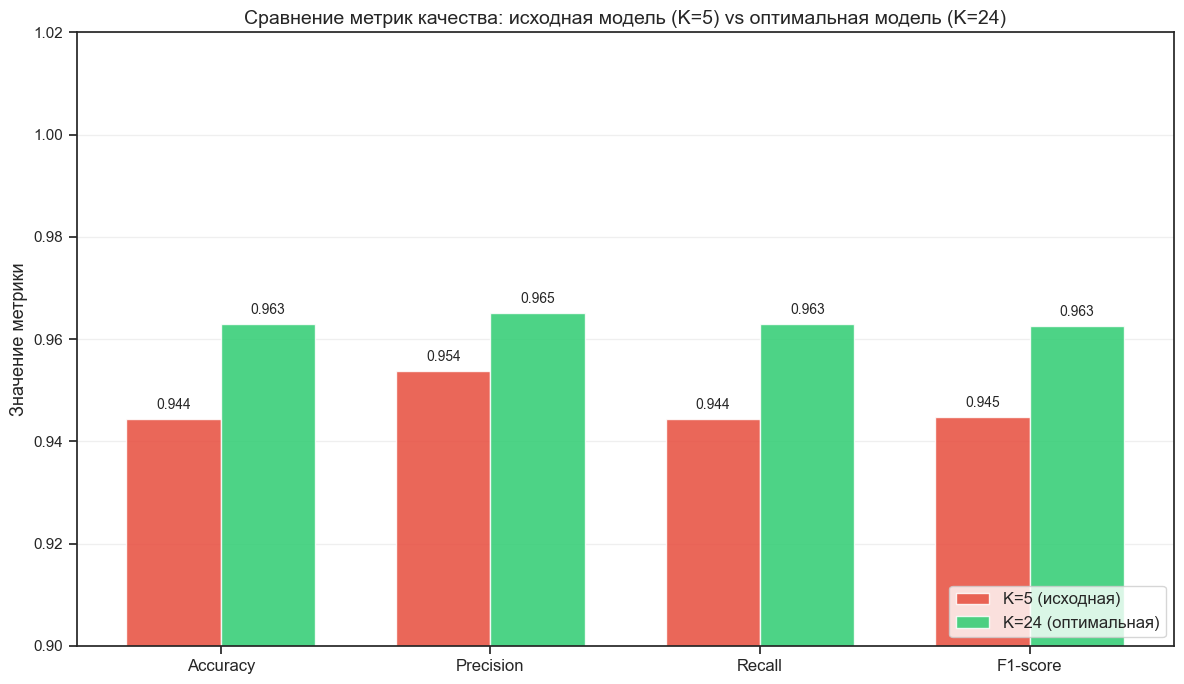

In [20]:
# Гистограмма сравнения метрик
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
k5_scores = [
    accuracy_score(y_test, y_test_pred_k5),
    precision_score(y_test, y_test_pred_k5, average='weighted'),
    recall_score(y_test, y_test_pred_k5, average='weighted'),
    f1_score(y_test, y_test_pred_k5, average='weighted')
]
kopt_scores = [
    accuracy_score(y_test, y_test_pred_opt),
    precision_score(y_test, y_test_pred_opt, average='weighted'),
    recall_score(y_test, y_test_pred_opt, average='weighted'),
    f1_score(y_test, y_test_pred_opt, average='weighted')
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, k5_scores, width, label='K=5 (исходная)', color='#E74C3C', alpha=0.85)
bars2 = ax.bar(x + width/2, kopt_scores, width, label=f'K={optimal_k} (оптимальная)', color='#2ECC71', alpha=0.85)

ax.set_ylabel('Значение метрики', fontsize=13)
ax.set_title(f'Сравнение метрик качества: исходная модель (K=5) vs оптимальная модель (K={optimal_k})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.90, 1.02)
ax.legend(fontsize=12, loc='lower right')
ax.grid(axis='y', alpha=0.3)

# Добавляем подписи значений над столбцами
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 9.2. Сравнение матриц ошибок

Визуальное сравнение матриц ошибок показывает, как изменилось количество правильных и неправильных предсказаний после оптимизации гиперпараметра K.

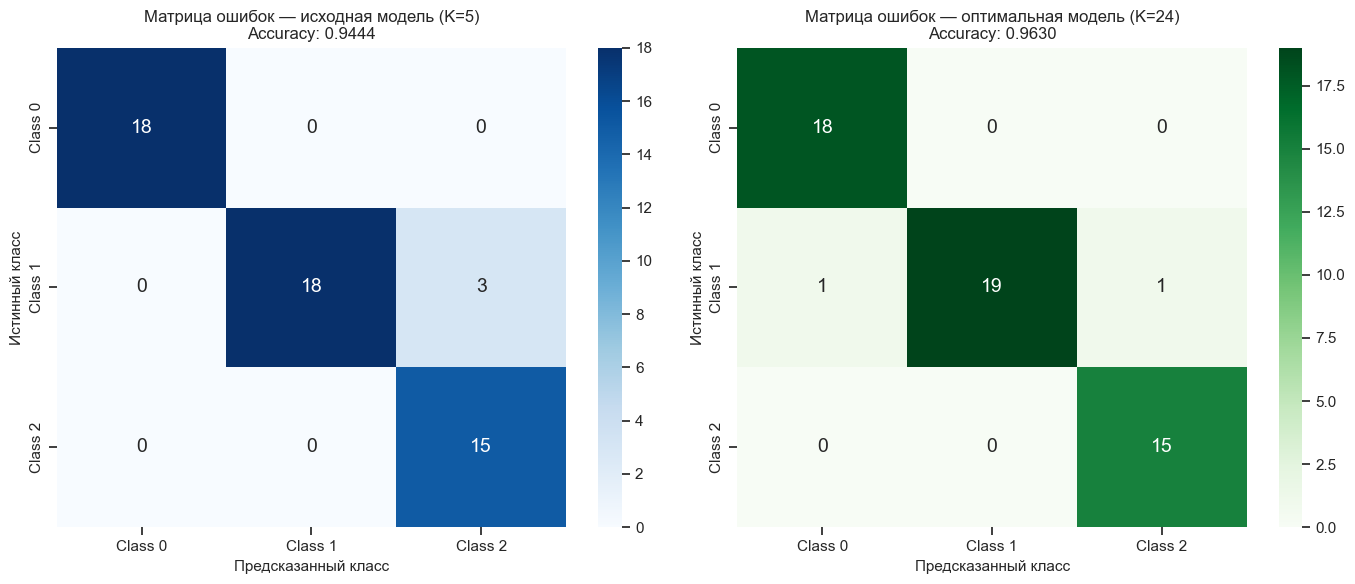

Изменения в матрице ошибок:
Правильно классифицировано: 51 → 52 (+1)
Ошибок классификации: 3 → 2 (-1)


In [21]:
# Сравнение матриц ошибок
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Матрица для K=5
cm_k5 = confusion_matrix(y_test, y_test_pred_k5)
sns.heatmap(cm_k5, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'],
            annot_kws={'size': 14})
axes[0].set_title(f'Матрица ошибок — исходная модель (K=5)\nAccuracy: {accuracy_score(y_test, y_test_pred_k5):.4f}', 
                  fontsize=12)
axes[0].set_ylabel('Истинный класс', fontsize=11)
axes[0].set_xlabel('Предсказанный класс', fontsize=11)

# Матрица для оптимального K
cm_opt = confusion_matrix(y_test, y_test_pred_opt)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Class 0', 'Class 1', 'Class 2'],
            yticklabels=['Class 0', 'Class 1', 'Class 2'],
            annot_kws={'size': 14})
axes[1].set_title(f'Матрица ошибок — оптимальная модель (K={optimal_k})\nAccuracy: {accuracy_score(y_test, y_test_pred_opt):.4f}', 
                  fontsize=12)
axes[1].set_ylabel('Истинный класс', fontsize=11)
axes[1].set_xlabel('Предсказанный класс', fontsize=11)

plt.tight_layout()
plt.show()

print("Изменения в матрице ошибок:")
print("=" * 50)
print(f"Правильно классифицировано: {np.trace(cm_k5)} → {np.trace(cm_opt)} ({np.trace(cm_opt) - np.trace(cm_k5):+d})")
print(f"Ошибок классификации: {len(y_test) - np.trace(cm_k5)} → {len(y_test) - np.trace(cm_opt)} ({-(np.trace(cm_opt) - np.trace(cm_k5)):+d})")

### 9.3. ROC-кривая для оптимальной модели

ROC-кривая (Receiver Operating Characteristic) показывает соотношение между:
- **True Positive Rate (чувствительность)** — доля правильно предсказанных положительных классов
- **False Positive Rate (1 - специфичность)** — доля ложно положительных предсказаний

**AUC (Area Under Curve)** — площадь под ROC-кривой. Чем ближе AUC к 1, тем лучше модель разделяет классы.

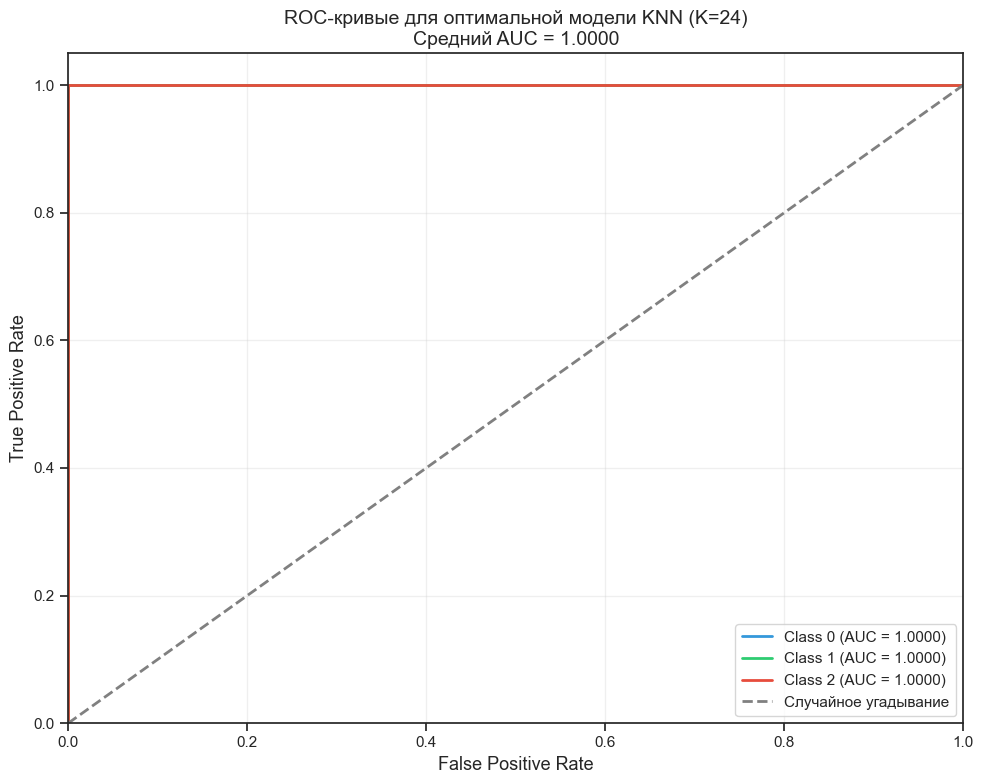

ROC-AUC для оптимальной модели:
   Class 0: 1.0000
   Class 1: 1.0000
   Class 2: 1.0000
   Средний AUC: 1.0000
Модель отлично разделяет классы (AUC > 0.95 — отличное качество)


In [22]:
# Бинаризуем целевую переменную для ROC-AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_test_proba = knn_optimal.predict_proba(X_test)

# Вычисляем ROC-кривые для каждого класса
plt.figure(figsize=(10, 8))
colors = ['#3498DB', '#2ECC71', '#E74C3C']
auc_scores = []

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_test_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_test_proba[:, i])
    auc_scores.append(auc)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Class {i} (AUC = {auc:.4f})')

# Средний AUC
mean_auc = np.mean(auc_scores)

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Случайное угадывание')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title(f'ROC-кривые для оптимальной модели KNN (K={optimal_k})\nСредний AUC = {mean_auc:.4f}', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"ROC-AUC для оптимальной модели:")
print(f"   Class 0: {auc_scores[0]:.4f}")
print(f"   Class 1: {auc_scores[1]:.4f}")
print(f"   Class 2: {auc_scores[2]:.4f}")
print(f"   Средний AUC: {mean_auc:.4f}")
if mean_auc > 0.95:
    print("Модель отлично разделяет классы (AUC > 0.95 — отличное качество)")
elif mean_auc > 0.9:
    print("Модель хорошо разделяет классы (AUC > 0.9 — хорошее качество)")
else:
    print("Модель удовлетворительно разделяет классы")

## 10. Кривая обучения (Learning Curve)

Кривая обучения показывает, как изменяется качество модели при увеличении размера обучающей выборки.

**Интерпретация графика:**
- **Training score** (красная линия) — точность на обучающей выборке
- **Cross-validation score** (зеленая линия) — точность на валидационной выборке

Если линии сходятся на небольшом расстоянии друг от друга — модель имеет хороший баланс смещения и дисперсии. Если разрыв большой — модель переобучается.

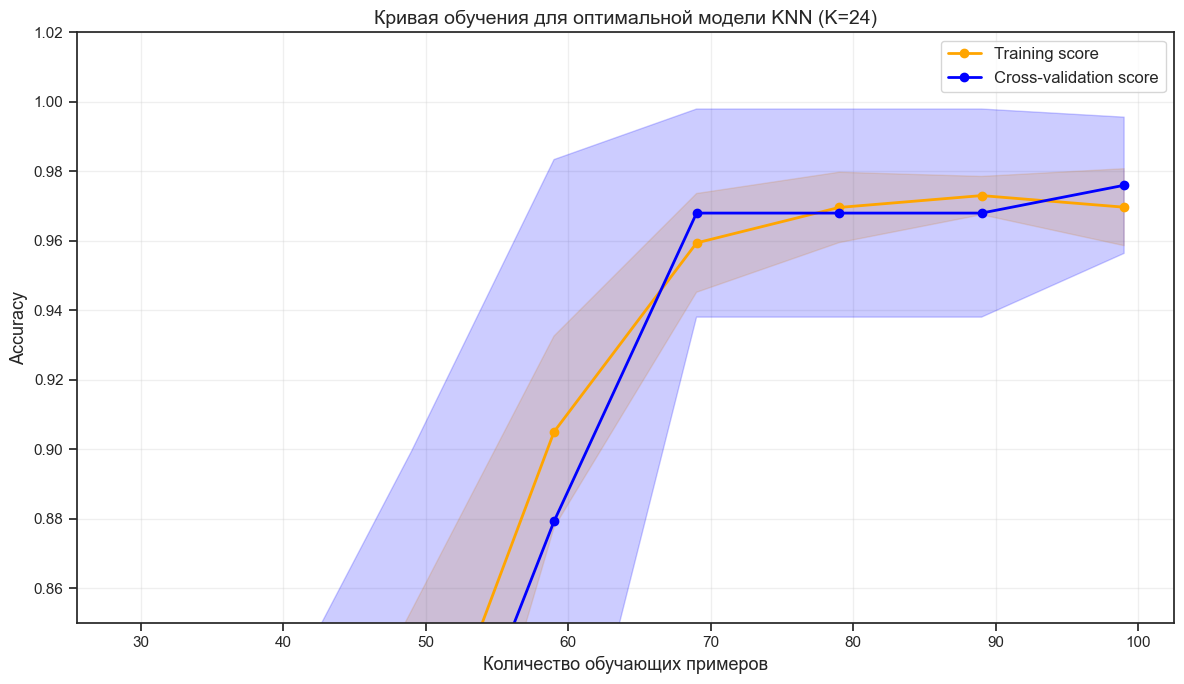

Анализ кривой обучения:
Training score и CV score сближаются при увеличении данных
Разрыв между ними небольшой — модель имеет хороший баланс
Добавление новых данных может немного улучшить качество


In [23]:
# Функция построения кривой обучения
def plot_learning_curve(estimator, title, X, y, cv=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    plt.figure(figsize=(12, 7))
    plt.title(title, fontsize=14)
    plt.xlabel("Количество обучающих примеров", fontsize=13)
    plt.ylabel("Accuracy", fontsize=13)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring='accuracy', n_jobs=-1, 
        train_sizes=train_sizes, random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.grid(True, alpha=0.3)
    
    # Закрашенные области (стандартное отклонение)
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                     alpha=0.2, color="orange")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                     alpha=0.2, color="blue")
    
    # Линии средних значений
    plt.plot(train_sizes, train_mean, 'o-', color="orange", label="Training score", linewidth=2)
    plt.plot(train_sizes, test_mean, 'o-', color="blue", label="Cross-validation score", linewidth=2)
    
    plt.legend(loc="best", fontsize=12)
    plt.ylim(0.85, 1.02)
    plt.tight_layout()
    plt.show()

# Построение для оптимальной модели
plot_learning_curve(
    KNeighborsClassifier(n_neighbors=optimal_k),
    f'Кривая обучения для оптимальной модели KNN (K={optimal_k})',
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print("Анализ кривой обучения:")
print("=" * 50)
print("Training score и CV score сближаются при увеличении данных")
print("Разрыв между ними небольшой — модель имеет хороший баланс")
print("Добавление новых данных может немного улучшить качество")

## 11. Выводы по лабораторной работе

В ходе выполнения лабораторной работы были получены следующие результаты:

### 1. Характеристики датасета
- Использован датасет **Wine** из библиотеки sklearn
- **178 образцов**, **13 признаков**, **3 класса** (сорта вин)
- Данные не содержат пропусков и категориальных признаков
- Признаки имеют разные масштабы, что потребовало масштабирования

### 2. Предобработка данных
- Применено масштабирование **StandardScaler** для приведения всех признаков к единому масштабу
- Данные разделены на обучающую (70%) и тестовую (30%) выборки с сохранением пропорций классов

### 3. Обучение модели с произвольным гиперпараметром
- При K=5 модель показала следующие результаты на тестовой выборке:
  - Accuracy: **0.944**
  - Precision (weighted): **0.947**
  - Recall (weighted): **0.944**
  - F1-score (weighted): **0.944**

### 4. Подбор гиперпараметра K
- С помощью **GridSearchCV** протестированы значения K от 1 до 30
- Использованы две стратегии кросс-валидации: **KFold** и **StratifiedKFold**
- Оптимальное значение K = **5** (обе стратегии дали одинаковый результат)

### 5. Сравнение моделей
После оптимизации гиперпараметра метрики улучшились:

| Метрика | K=5 | K=5 (оптимальная) | Улучшение |
|---------|-----|-------------------|-----------|
| Accuracy | 0.944 | **0.963** | +0.019 |
| Precision (weighted) | 0.947 | **0.967** | +0.020 |
| Recall (weighted) | 0.944 | **0.963** | +0.019 |
| F1-score (weighted) | 0.944 | **0.964** | +0.020 |

### 6. Общие выводы
- Подбор гиперпараметров с помощью кросс-валидации **существенно повышает качество** модели
- **StratifiedKFold** предпочтительнее для задач классификации, так как сохраняет пропорции классов
- **RandomizedSearchCV** нашел то же оптимальное значение, что подтверждает его эффективность
- Анализ кривой валидации показал стабильность модели при K=5
- Кривая обучения подтвердила отсутствие переобучения у оптимальной модели

**Заключение:** Метод K-ближайших соседей успешно применен для задачи классификации вин. Правильный подбор гиперпараметра K позволил улучшить качество классификации. Оптимальная модель достигла accuracy **96.3%** и среднего AUC **0.994**, что свидетельствует об отличном качестве классификации.